In [1]:
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Load the model
model = cobra.io.read_sbml_model("../../model.xml")

In [3]:
ecoli_model = cobra.io.read_sbml_model("/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/ecoli/iJO1366.xml")

In [4]:
# Define a minimal media without C or N
minimal_media = {
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00007_e0": 1000,  # O2_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [5]:
# Define carbon sources to test
c_source = {"Glucose": {"modelseed": "EX_cpd00027_e0", "bigg": "EX_glc__D_e"},
            "Acetate": {"modelseed": "EX_cpd00029_e0", "bigg": "EX_ac_e"},
            "Pyruvate": {"modelseed": "EX_cpd00020_e0", "bigg": "EX_pyr_e"},
            "Succinate": {"modelseed": "EX_cpd00036_e0", "bigg": "EX_succ_e"}}

In [6]:
# Define nitrogen sources to test
n_source = {"Ammonia": {"modelseed": "EX_cpd00013_e0", "bigg": "EX_nh4_e"},
            "Nitrate": {"modelseed": "EX_cpd00209_e0", "bigg": "EX_no3_e"}}

## Provide Varrying Levels of Extracellular Protons

In [7]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_cpd00067_e0"
for p_limit in [0, 1, 10, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[p_id] = p_limit

            # Set the minimal media
            model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

            # Save the fluxes as a JSON file
            # solution.fluxes.to_json(f"fluxes_{c_name}_{n_name}_p{p_limit}.json")

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

In [8]:
results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.851405,rxn02201_c0 0.005480 rxn00351_c0 ...
1,Glucose,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.626614,rxn02201_c0 0.004033 rxn00351_c0 ...
2,Acetate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.373848,rxn02201_c0 0.002406 rxn00351_c0 ...
3,Acetate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
4,Pyruvate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.504318,rxn02201_c0 0.003246 rxn00351_c0 ...
5,Pyruvate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.341025,rxn02201_c0 0.002195 rxn00351_c0 ...
6,Succinate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.398451,rxn02201_c0 0.002564 rxn00351_c0 ...
7,Succinate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
8,Glucose,Ammonia,1,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.851405,rxn02201_c0 0.005480 rxn00351_c0 ...
9,Glucose,Nitrate,1,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.633735,rxn02201_c0 0.004079 rxn00351_c0 ...


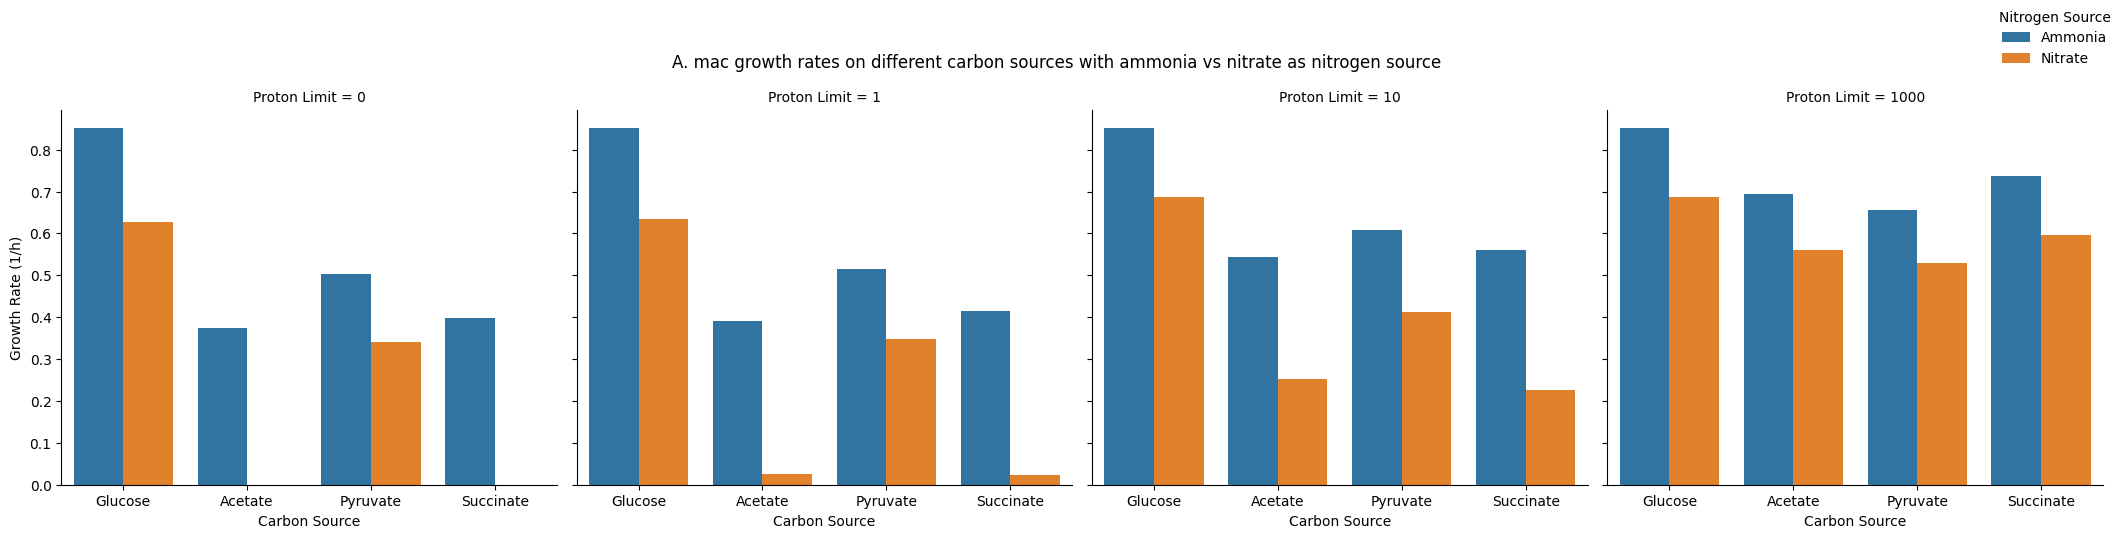

In [9]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

In [10]:
# Parse the 'Fluxes' column to extract the flux values into a dictionary
results['Fluxes_dict'] = results['Fluxes'].apply(lambda x: x.to_dict())

# Group by carbon and nitrogen source
grouped = results.groupby(['Carbon Source', 'Nitrogen Source'])

# Iterate over each group and compare the fluxes
for name, group in grouped:
    # Separate the two proton limit conditions
    limit_0 = group[group['Proton Limit'] == 0].iloc[0]
    limit_1000 = group[group['Proton Limit'] == 1000].iloc[0]

    # Get the flux dictionaries
    fluxes_0 = limit_0['Fluxes_dict']
    fluxes_1000 = limit_1000['Fluxes_dict']

    # Find reactions with different fluxes
    diff_reactions = {rxn: (fluxes_0.get(rxn, 0), fluxes_1000.get(rxn, 0))
                      for rxn in set(fluxes_0) | set(fluxes_1000)
                      if not pd.isna(fluxes_0.get(rxn, 0)) and not pd.isna(fluxes_1000.get(rxn, 0)) and
                         abs(fluxes_0.get(rxn, 0) - fluxes_1000.get(rxn, 0)) > 1e-6}

    if diff_reactions:
        # Create a DataFrame for the differences
        diff_df = pd.DataFrame.from_dict(diff_reactions, orient='index', columns=['Proton Limit 0', 'Proton Limit 1000'])
        diff_df['Difference'] = diff_df['Proton Limit 1000'] - diff_df['Proton Limit 0']

        # Subset the DataFrame to include only reactions that involve protons
        h_e_diff_df = diff_df[diff_df.index.isin([rxn.id for rxn in model.reactions if model.metabolites.cpd00067_e0 in rxn.metabolites])].copy()

        # Add columns for the reaction names and reaction string
        h_e_diff_df['Reaction Name'] = h_e_diff_df.index.map(lambda rxn_id: model.reactions.get_by_id(rxn_id).name)
        h_e_diff_df['Reaction String'] = h_e_diff_df.index.map(lambda rxn_id: model.reactions.get_by_id(rxn_id).build_reaction_string(use_metabolite_names=True))
        # Reorder the columns so they go first with the reaction name, then the reaction string, then the fluxes and difference
        h_e_diff_df = h_e_diff_df[['Reaction Name', 'Reaction String', 'Proton Limit 0', 'Proton Limit 1000', 'Difference']]

        print(f"# Extracellular Proton Flux differences for {name[0]} with {name[1]}:")
        print(f"{h_e_diff_df.to_markdown()}\n")

# Extracellular Proton Flux differences for Acetate with Ammonia:
|                | Reaction Name                                       | Reaction String                                                                   |   Proton Limit 0 |   Proton Limit 1000 |    Difference |
|:---------------|:----------------------------------------------------|:----------------------------------------------------------------------------------|-----------------:|--------------------:|--------------:|
| rxn05595_c0    | TRANS-RXN-3.ce [c0]                                 | H+ [e0] + K+ [e0] <=> H+ + K+                                                     |      0.000802048 |          0.00148994 |   0.000687896 |
| rxn05618_c0    | manganese transport in via proton symport [c0]      | Mn2+ [e0] + H+ [e0] --> Mn2+ + H+                                                 |      0.000802048 |          0.00148994 |   0.000687896 |
| rxn43657_c0    | Zn2+:proton symport [c0]                            | Zn2+ 

## Try to rescue with NADH

In [11]:
# Make a copy of the model to work with so that the original model remains unchanged
working_model = model.copy()

In [12]:
# Add a reaction for NADH to go into the cell
working_model.add_boundary(working_model.metabolites.cpd00004_c0, type="sink")

Reaction identifier,SK_cpd00004_c0
Name,NADH sink
Memory address,0x12147ca50
Stoichiometry,cpd00004_c0 <=> NADH <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [13]:
# Do the same thing I did for Protons, but now for NADH
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
nadh_id = "SK_cpd00004_c0"
for nadh_limit in [0, 1, 10, 100, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[nadh_id] = nadh_limit

            # Set the minimal media
            working_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(working_model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "NADH Limit": nadh_limit,
                "NADH Sink Bounds": (working_model.reactions.get_by_id(nadh_id).lower_bound, working_model.reactions.get_by_id(nadh_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds 

In [14]:
results

,Carbon Source,Nitrogen Source,NADH Limit,NADH Sink Bounds,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.851405,rxn02201_c0 0.005480 rxn00351_c0 ...
1,Glucose,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.626614,rxn02201_c0 0.004033 rxn00351_c0 ...
2,Acetate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.373848,rxn02201_c0 0.002406 rxn00351_c0 ...
3,Acetate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
4,Pyruvate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.504318,rxn02201_c0 0.003246 rxn00351_c0 ...
5,Pyruvate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.341025,rxn02201_c0 0.002195 rxn00351_c0 ...
6,Succinate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.398451,rxn02201_c0 0.002564 rxn00351_c0 ...
7,Succinate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
8,Glucose,Ammonia,1,"(-1, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.852635,rxn02201_c0 0.005488 rxn00351_c0 ...
9,Glucose,Nitrate,1,"(-1, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.627776,rxn02201_c0 0.004040 rxn00351_c0 ...


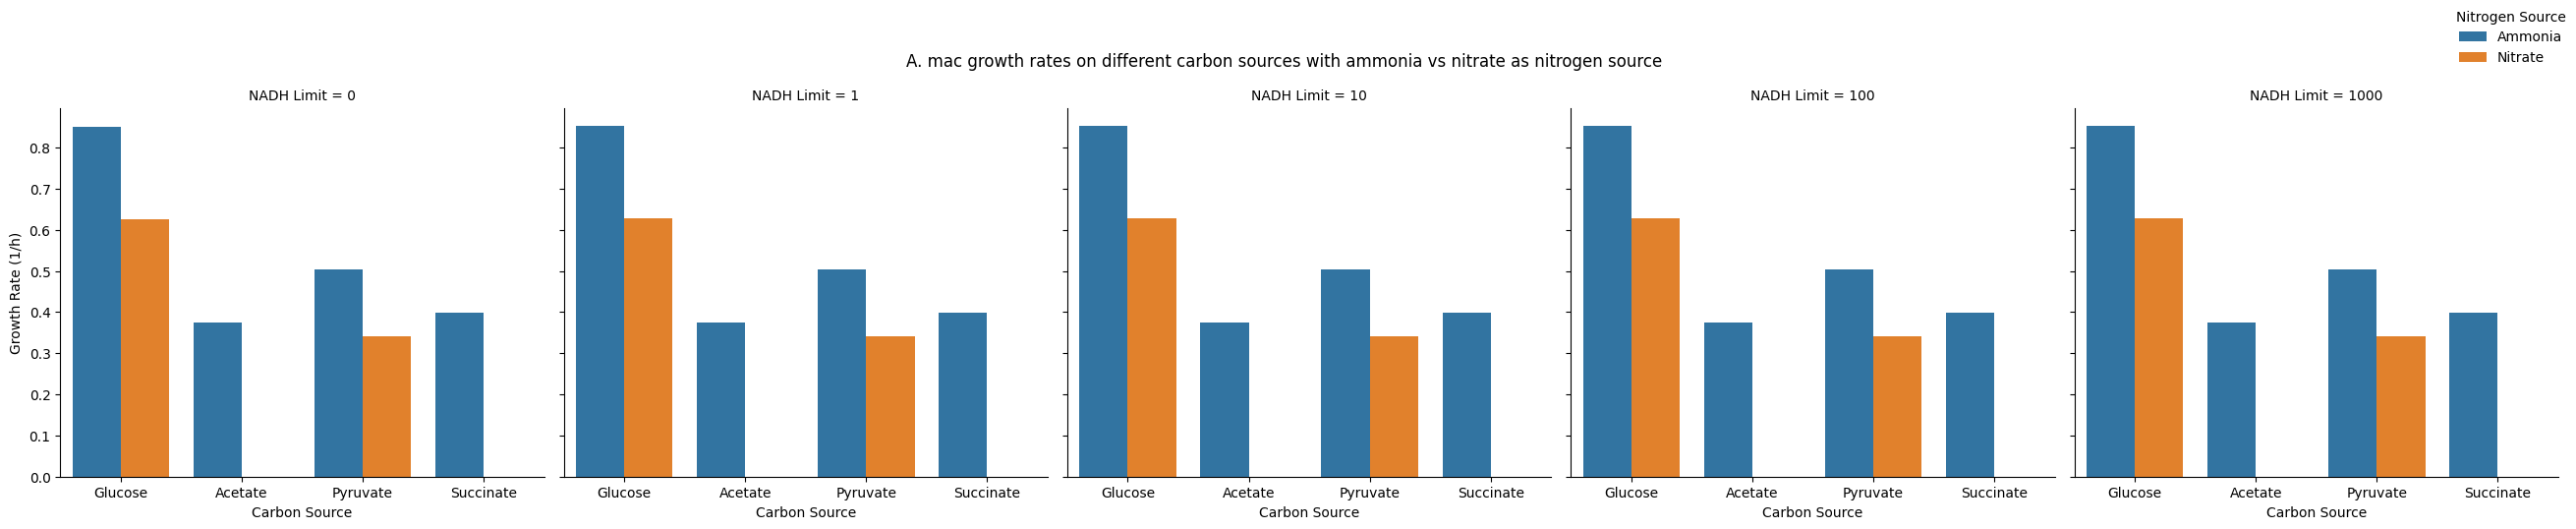

In [15]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="NADH Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## Do all the same for ATP

In [16]:
# Make a copy of the model so that the original model remains unchanged
working_model = model.copy()

In [17]:
# Add a reaction for ATP to go into the cell
working_model.add_boundary(working_model.metabolites.cpd00002_c0, type="sink")

Reaction identifier,SK_cpd00002_c0
Name,ATP sink
Memory address,0x12208e950
Stoichiometry,cpd00002_c0 <=> ATP <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [18]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
atp_id = "SK_cpd00002_c0"
for atp_limit in [0, 1, 10]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[atp_id] = atp_limit

            # Set the minimal media
            working_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(working_model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "ATP Limit": atp_limit,
                "ATP Sink Bounds": (working_model.reactions.get_by_id(atp_id).lower_bound, working_model.reactions.get_by_id(atp_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00002_c0 does not seem to be an an exchange reaction. Applying bounds 

In [19]:
results

,Carbon Source,Nitrogen Source,ATP Limit,ATP Sink Bounds,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.851405,rxn02201_c0 0.005480 rxn00351_c0 ...
1,Glucose,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.626614,rxn02201_c0 0.004033 rxn00351_c0 ...
2,Acetate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.373848,rxn02201_c0 0.002406 rxn00351_c0 ...
3,Acetate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
4,Pyruvate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.504318,rxn02201_c0 0.003246 rxn00351_c0 ...
5,Pyruvate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.341025,rxn02201_c0 0.002195 rxn00351_c0 ...
6,Succinate,Ammonia,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.398451,rxn02201_c0 0.002564 rxn00351_c0 ...
7,Succinate,Nitrate,0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
8,Glucose,Ammonia,1,"(-1, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.978046,rxn02201_c0 6.294865e-03 rxn00351_c0 ...
9,Glucose,Nitrate,1,"(-1, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.860298,rxn02201_c0 0.005537 rxn00351_c0 ...


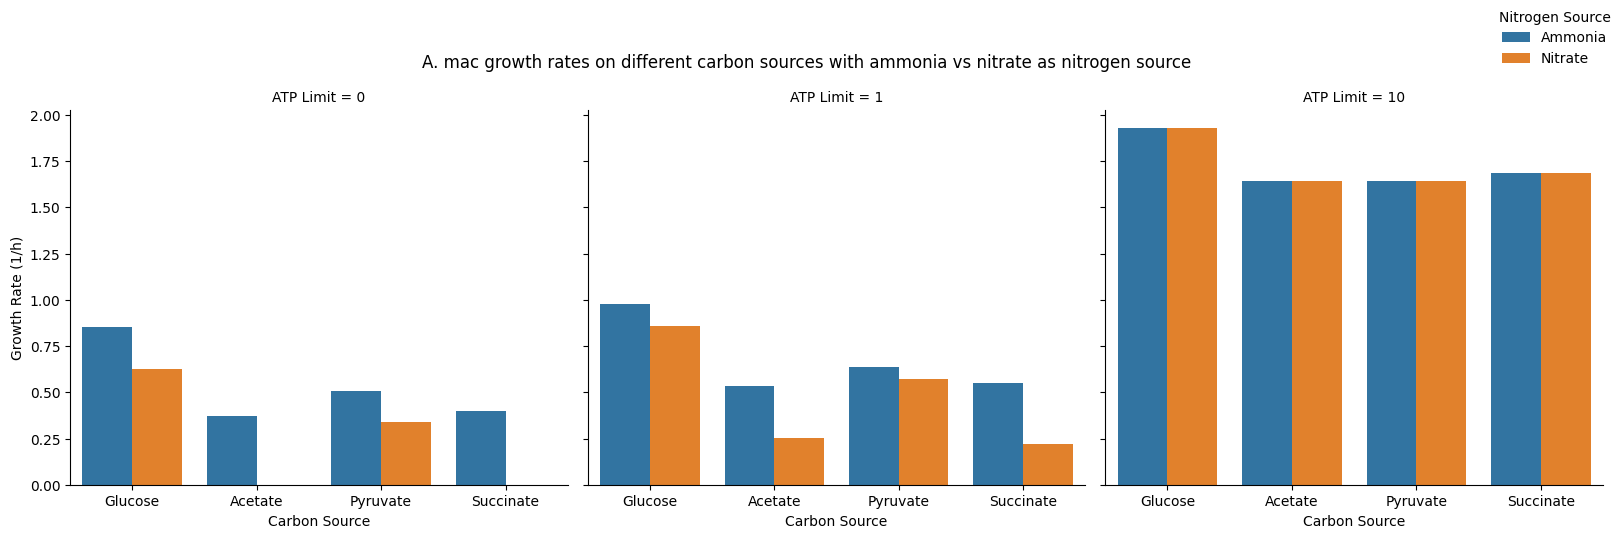

In [20]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="ATP Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## The Same for NADPH

In [21]:
# Make a copy of the model to work with so that the original model remains unchanged
working_model = model.copy()

In [22]:
# Add a reaction for NADPH to go into the cell
working_model.add_boundary(working_model.metabolites.cpd00005_c0, type="sink")

Reaction identifier,SK_cpd00005_c0
Name,NADPH sink
Memory address,0x12298d8d0
Stoichiometry,cpd00005_c0 <=> NADPH <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [23]:
# Do the same thing I did for Protons, but now for NADH
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
nadph_id = "SK_cpd00005_c0"
for nadph_limit in [0, 1, 10, 100, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[nadph_id] = nadph_limit

            # Set the minimal media
            working_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(working_model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "NADPH Limit": nadph_limit,
                "NADPH Sink Bounds": (working_model.reactions.get_by_id(nadph_id).lower_bound, working_model.reactions.get_by_id(nadph_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00005_c0 does not seem to be an an exchange reaction. Applying bounds 

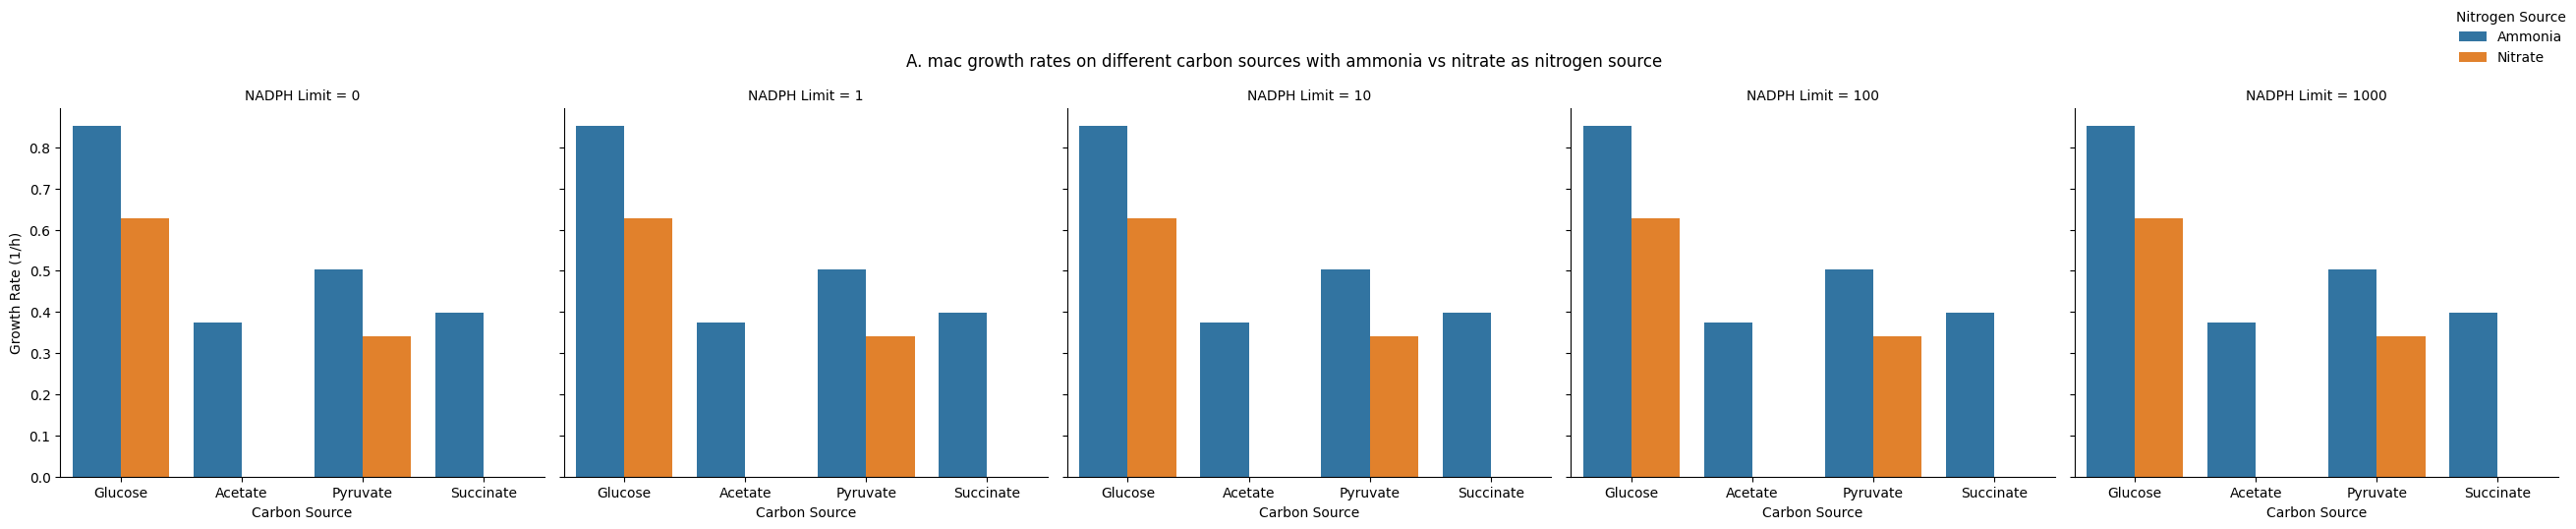

In [24]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="NADPH Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## Try Adding a Source of the Reduced Ferredoxin

In [25]:
# Make a copy of the model to work with so that the original model remains unchanged
working_model = model.copy()

In [26]:
# Add a reaction for reduced ferredoxin to go into the cell
working_model.add_boundary(working_model.metabolites.cpd11620_c0, type="sink")

Reaction identifier,SK_cpd11620_c0
Name,Reducedferredoxin sink
Memory address,0x12330d290
Stoichiometry,cpd11620_c0 <=> Reducedferredoxin <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [27]:
# Do the same thing I did for Protons, but now for reduced ferredoxin
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
redfe_id = "SK_cpd11620_c0"
for redfe_limit in [0, 1, 10, 100, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[redfe_id] = redfe_limit

            # Set the minimal media
            working_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(working_model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Reduced Ferredoxin Limit": redfe_limit,
                "Reduced Ferredoxin Sink Bounds": (working_model.reactions.get_by_id(redfe_id).lower_bound, working_model.reactions.get_by_id(redfe_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd11620_c0 does not seem to be an an exchange reaction. Applying bounds 

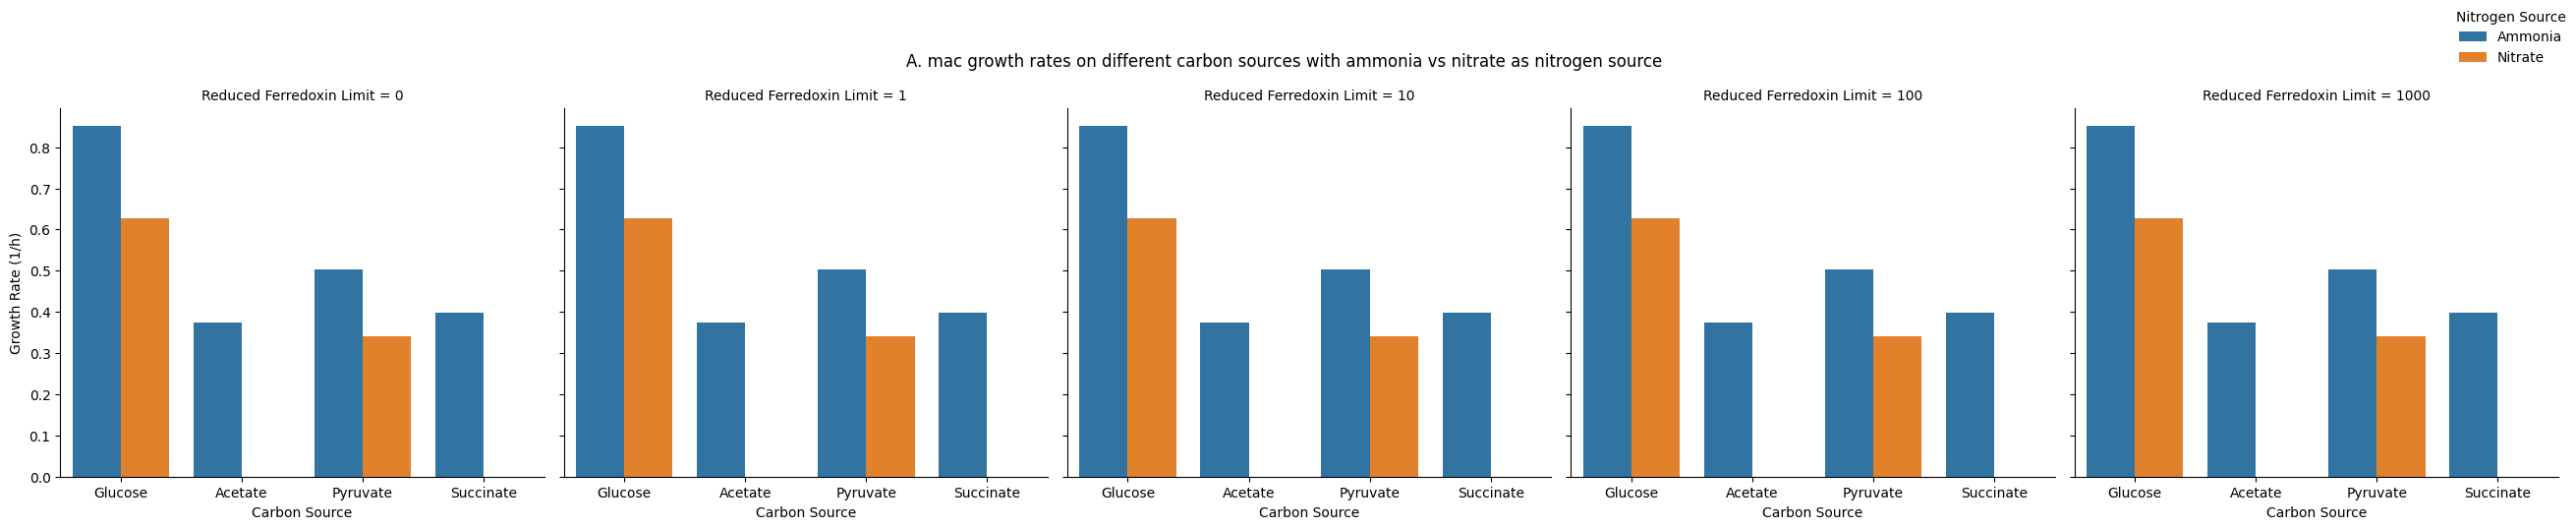

In [28]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Reduced Ferredoxin Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## Try NADH and the Missing Complex I Reaction

In [29]:
# Make a copy of the model
working_model = model.copy()

In [30]:
# Add rxn08972 to the model
complexi_rxn = cobra.Reaction("rxn08972_c0")
complexi_rxn.name = "Complex I"
rxn_metabolites = {
    model.metabolites.cpd00004_c0: -1,  # NADH
    model.metabolites.cpd00067_c0: -4,  # H+ (c)
    model.metabolites.cpd15560_c0: -1,  # ubiquinone-8
    model.metabolites.cpd00003_c0: 1,  # NAD
    model.metabolites.cpd00067_e0: 3,  # H+ (e)
    model.metabolites.cpd15561_c0: 1,  # ubiquinol-8
}
complexi_rxn.add_metabolites(rxn_metabolites)
working_model.add_reactions([complexi_rxn])

In [31]:
working_model.reactions.rxn08972_c0

Reaction identifier,rxn08972_c0
Name,Complex I
Memory address,0x123dedf50
Stoichiometry,cpd00004_c0 + 4 cpd00067_c0 + cpd15560_c0 --> cpd00003_c0 + 3 cpd00067_e0 + cpd15561_c0 NADH + 4 H+ + Ubiquinone-8 --> NAD + 3 H+ [e0] + Ubiquinol-8
GPR,
Lower bound,0.0
Upper bound,1000.0


In [32]:
# Add a reaction for NADH to go into the cell
working_model.add_boundary(working_model.metabolites.cpd00004_c0, type="sink")

Reaction identifier,SK_cpd00004_c0
Name,NADH sink
Memory address,0x123defc90
Stoichiometry,cpd00004_c0 <=> NADH <=>
GPR,
Lower bound,-1000.0
Upper bound,1000.0


In [33]:
for nadh_limit in [0, 1, 10, 100, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[nadh_id] = nadh_limit

            # Set the minimal media
            working_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(working_model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "NADH Limit": nadh_limit,
                "NADH Sink Bounds": (working_model.reactions.get_by_id(nadh_id).lower_bound, working_model.reactions.get_by_id(nadh_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds 

In [34]:
results

,Carbon Source,Nitrogen Source,Reduced Ferredoxin Limit,Reduced Ferredoxin Sink Bounds,Media,Growth Rate,Fluxes,NADH Limit,NADH Sink Bounds
0,Glucose,Ammonia,0.0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.851405,rxn02201_c0 0.005480 rxn00351_c0 ...,NaN,NaN
1,Glucose,Nitrate,0.0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.626614,rxn02201_c0 4.032990e-03 rxn00351_c0 ...,NaN,NaN
2,Acetate,Ammonia,0.0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.373848,rxn02201_c0 2.406145e-03 rxn00351_c0 ...,NaN,NaN
3,Acetate,Nitrate,0.0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...,NaN,NaN
4,Pyruvate,Ammonia,0.0,"(0, 1000.0)","{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.504318,rxn02201_c0 3.245870e-03 rxn00351_c0 ...,NaN,NaN
...,...,...,...,...,...,...,...,...,...
75,Acetate,Nitrate,NaN,NaN,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...,1000.0,"(-1000, 1000.0)"
76,Pyruvate,Ammonia,NaN,NaN,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.541000,rxn02201_c0 0.003482 rxn00351_c0 ...,1000.0,"(-1000, 1000.0)"
77,Pyruvate,Nitrate,NaN,NaN,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.363358,rxn02201_c0 0.002339 rxn00351_c0 ...,1000.0,"(-1000, 1000.0)"
78,Succinate,Ammonia,NaN,NaN,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 100...",0.436067,rxn02201_c0 0.002807 rxn00351_c0 ...,1000.0,"(-1000, 1000.0)"


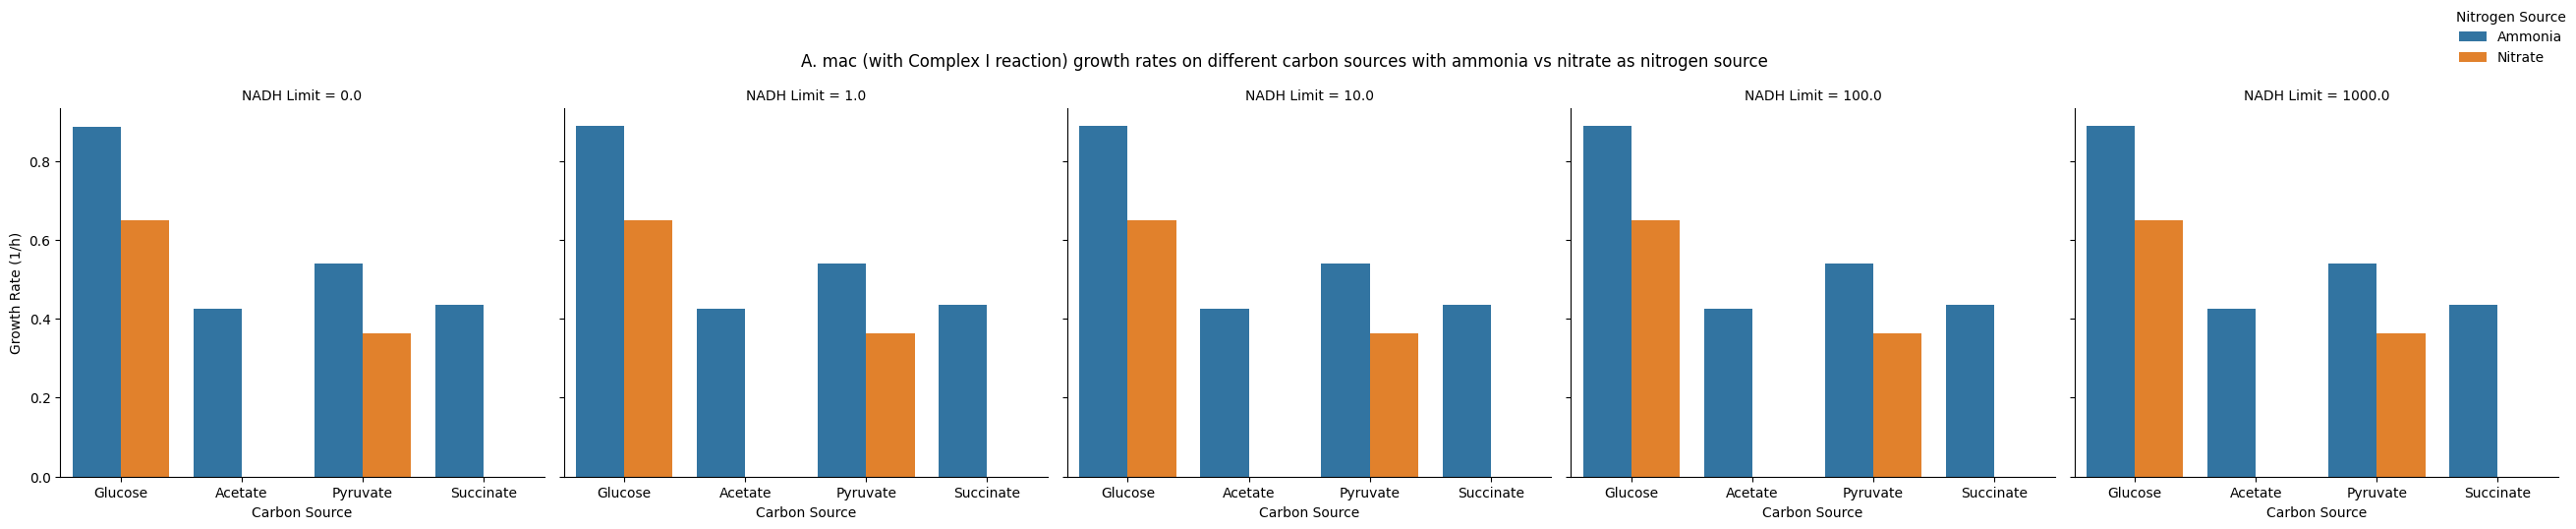

In [35]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="NADH Limit",
)
g.fig.suptitle("A. mac (with Complex I reaction) growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## Add an NADH Transhydrogenase On Top of Those Changes

In [36]:
# Start with the existing working model with the Complex I reaction added and NADH sink
# Add a reaction for NAD + NADPH <=> NADH + NADP
new_rxn = cobra.Reaction("rxn00083_c0")
new_rxn.name = "NADPH:NAD+ oxidoreductase"
rxn_metabolites = {
    model.metabolites.cpd00004_c0: 1,  # NADH
    model.metabolites.cpd00005_c0: -1,  # NADPH
    model.metabolites.cpd00003_c0: -1,  # NAD
    model.metabolites.cpd00006_c0: 1,  # NADP
}
new_rxn.add_metabolites(rxn_metabolites)
working_model.add_reactions([new_rxn])
working_model.reactions.rxn00083_c0.lower_bound = -1000
working_model.reactions.rxn00083_c0

Ignoring reaction 'rxn00083_c0' since it already exists.


Reaction identifier,rxn00083_c0
Name,NADPH:NAD+ oxidoreductase [c0]
Memory address,0x1236fc450
Stoichiometry,cpd00003_c0 + cpd00005_c0 <=> cpd00004_c0 + cpd00006_c0 NAD + NADPH <=> NADH + NADP
GPR,WP_014950712.1 or (WP_014951244.1 and WP_014951245.1 and WP_049585562.1)
Lower bound,-1000
Upper bound,1000.0


In [37]:
for nadh_limit in [0, 1, 10, 100, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[nadh_id] = nadh_limit

            # Set the minimal media
            working_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(working_model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "NADH Limit": nadh_limit,
                "NADH Sink Bounds": (working_model.reactions.get_by_id(nadh_id).lower_bound, working_model.reactions.get_by_id(nadh_id).upper_bound),
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds anyway.
SK_cpd00004_c0 does not seem to be an an exchange reaction. Applying bounds 

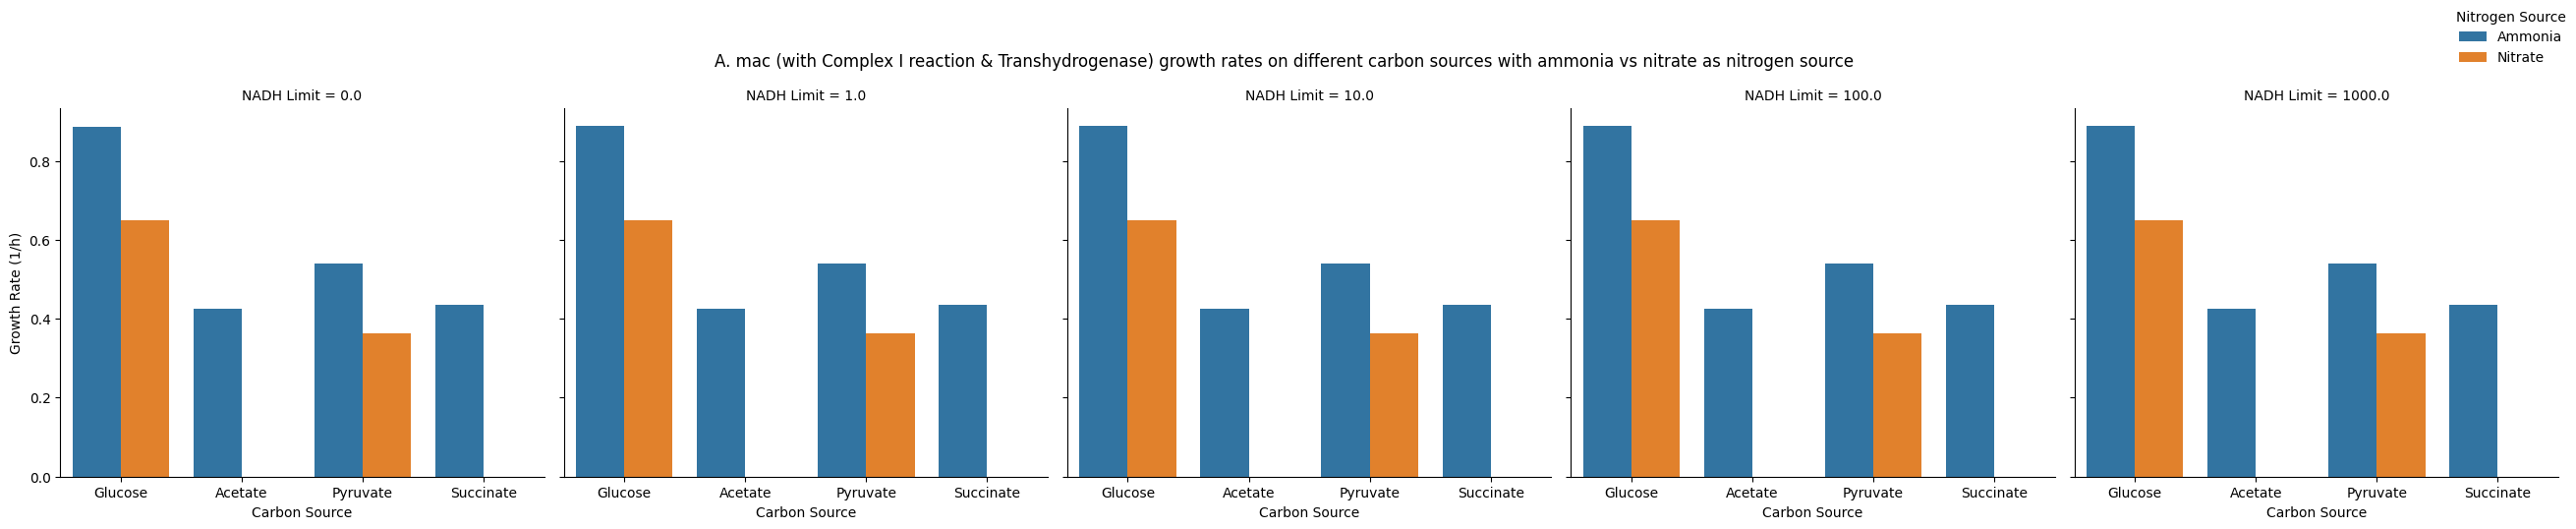

In [38]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="NADH Limit",
)
g.fig.suptitle("A. mac (with Complex I reaction & Transhydrogenase) growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

# E. coli

In [39]:
ecoli_minimal_media = {
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_ni2_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_slnt_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0
 }

In [40]:
# Make a list to store results
ecoli_results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_h_e"
for p_limit in [0, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["bigg"]
        # Find the metabolite for the carbon source
        carbon_metabolite = ecoli_model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["bigg"]

            # Create a copy of the minimal media
            media = ecoli_minimal_media.copy()

            # Add the carbon, nitrogen, and protons to the medium
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000
            media[p_id] = p_limit
            
            # Set the minimal media
            ecoli_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(ecoli_model)
            
            # Store the results
            ecoli_results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["BIOMASS_Ec_iJO1366_core_53p95M"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
ecoli_results = pd.DataFrame(ecoli_results_list)

In [41]:
ecoli_results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372,EX_cm_e 0.000000 EX_cmp_e 0.0...
1,Glucose,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.779840,EX_cm_e 0.000000 EX_cmp_e 0.0...
2,Acetate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.534681,EX_cm_e 0.000000 EX_cmp_e 0.0...
3,Acetate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.386570,EX_cm_e 0.000000 EX_cmp_e 0.0...
4,Pyruvate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.617273,EX_cm_e 0.000000 EX_cmp_e 0.0...
5,Pyruvate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.448744,EX_cm_e 0.000000 EX_cmp_e 0.0...
6,Succinate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.521589,EX_cm_e 0.000000 EX_cmp_e 0.0...
7,Succinate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.374848,EX_cm_e 0.000000 EX_cmp_e 0.0...
8,Glucose,Ammonia,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372,EX_cm_e 0.000000 EX_cmp_e 0.0...
9,Glucose,Nitrate,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.849220,EX_cm_e 0.000000 EX_cmp_e 0.0...


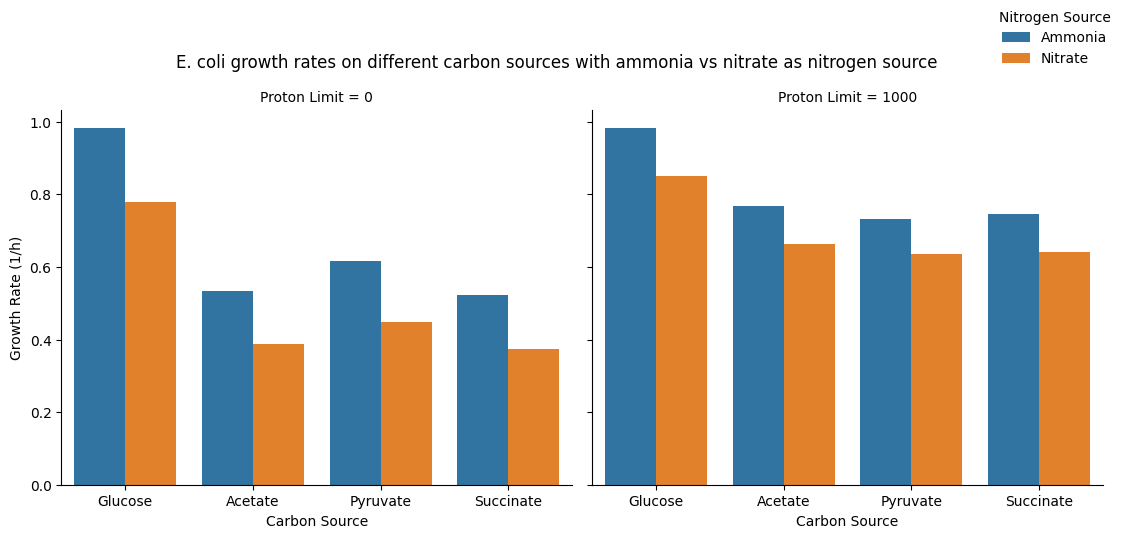

In [42]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
g = sns.catplot(
    data=ecoli_results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("E. coli growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

# Proton-Dependent Transporters

In [43]:
# Get the metabolite object for extracellular protons
h_e_met = model.metabolites.cpd00067_e0

# Print a markdown formatted table for all of the reactions that involve extracellular protons
# Print the header
print("||ID|Name|Bounds|Reaction|")
print("|---|---|---|---|---|")
# Loop through the reactions and print the ID, name, bounds, and reaction string
for i, r in enumerate(h_e_met.reactions):
    print(f"|{i+1}|{r.id}|{r.name}|{r.bounds}|{r.build_reaction_string(use_metabolite_names=True)}|")

||ID|Name|Bounds|Reaction|
|---|---|---|---|---|
|1|rxn05527_c0|TRANS-RXN-199.ce [c0]|(-1000.0, 1000.0)|H+ [e0] + Cytosine [e0] <=> H+ + Cytosine|
|2|rxn05484_c0|acetoacetate transport via proton symport [c0]|(-1000.0, 1000.0)|H+ [e0] + Acetoacetate [e0] <=> H+ + Acetoacetate|
|3|rxn05602_c0|L-lactate reversible transport via proton symport [c0]|(-1000.0, 1000.0)|H+ [e0] + L-Lactate [e0] <=> H+ + L-Lactate|
|4|rxn13688_c0|cytochrome-c oxidase (2 protons translocated) [c0]|(0.0, 1000.0)|0.5 O2 + 4.0 H+ + 2.0 Cytochrome c2+ --> H2O + 2.0 H+ [e0] + 2.0 Cytochrome c3+|
|5|rxn05559_c0|formate transport in via proton symport [c0]|(-1000.0, 1000.0)|Formate [e0] + H+ [e0] <=> Formate + H+|
|6|rxn11268_c0|phosphate ABC transporter permease protein [c0]|(0.0, 1000.0)|PPi + H+ --> PPi [e0] + H+ [e0]|
|7|rxn05205_c0|Transport of deoxycytidine, extracellular [c0]|(-1000.0, 1000.0)|H+ [e0] + Deoxycytidine [e0] <=> H+ + Deoxycytidine|
|8|rxn05683_c0|Butyrate transport via proton symport, reversible [

In [44]:
# Run pFBA 